# Optimización de asignaciones — Comparación de técnicas (SI1)

Este notebook resuelve el **mismo problema** de asignación de solicitudes
universitarias a funcionarios con cuatro técnicas y las **compara**:

| Técnica | Familia (rúbrica SI1) |
|---|---|
| **A\*** | Búsqueda Informada |
| **BFS / DFS** | Búsqueda No Informada |
| **Algoritmo Genético** | Metaheurística |

Y grafica: barras comparativas (costo, esfuerzo, tiempo), el **árbol de búsqueda
de A\***, y la **curva de convergencia** del genético.


## 1. Dependencias
Solo `matplotlib` y `networkx` (para el grafo del árbol).

In [1]:
!pip -q install matplotlib networkx

## 2. Modelo del problema

- **Solicitud**: id, categoría, prioridad.
- **Funcionario**: id, especialidad (= categoría que atiende), carga actual,
  tiempo promedio de respuesta, horas de disponibilidad.
- **Costo** de asignar una solicitud a un funcionario: combina su carga y su
  tiempo de respuesta (normalizados), más una penalización si la solicitud es
  de prioridad **Alta** pero el funcionario está saturado o es lento.

In [2]:
from dataclasses import dataclass, field

@dataclass(frozen=True)
class Solicitud:
    id: int
    categoria: str
    prioridad: str   # "Alta" | "Media" | "Baja"

@dataclass(frozen=True)
class Funcionario:
    id: int
    nombre: str
    especialidad: str
    carga_actual: int
    tiempo_promedio_respuesta: float
    disponibilidad_horas: int

# Pesos y umbrales de la función de costo
PESO_CARGA = 1.0
PESO_TIEMPO = 1.0
PENALIZACION_URGENCIA = 2.0
UMBRAL_CARGA_ALTA = 4
UMBRAL_TIEMPO_LENTO = 2.0

def _norm(valor, maximo):
    if maximo <= 0:
        return 0.0
    return min(max(valor / maximo, 0.0), 1.0)

def costo_asignacion(sol, func, max_carga, max_tiempo):
    """g(n): costo de asignar `sol` a `func`."""
    c = PESO_CARGA * _norm(func.carga_actual, max_carga)
    c += PESO_TIEMPO * _norm(func.tiempo_promedio_respuesta, max_tiempo)
    urgente = sol.prioridad == "Alta"
    saturado = func.carga_actual >= UMBRAL_CARGA_ALTA
    lento = func.tiempo_promedio_respuesta >= UMBRAL_TIEMPO_LENTO
    if urgente and (saturado or lento):
        c += PENALIZACION_URGENCIA
    return c

def candidatos_por_solicitud(solicitudes, funcionarios):
    """Para cada solicitud, índices de funcionarios con la especialidad correcta."""
    return [
        [j for j, f in enumerate(funcionarios) if f.especialidad == s.categoria]
        for s in solicitudes
    ]

def tabla_costos(solicitudes, funcionarios, candidatos):
    max_carga = max((f.carga_actual for f in funcionarios), default=0) or 1
    max_tiempo = max((f.tiempo_promedio_respuesta for f in funcionarios), default=0) or 1
    costos = {}
    for i, s in enumerate(solicitudes):
        for j in candidatos[i]:
            costos[(i, j)] = costo_asignacion(s, funcionarios[j], max_carga, max_tiempo)
    return costos

## 3. Obtener datos desde la API (sin conectarse a la BD)

El notebook pide los datos a tu **app desplegada** (que ya está conectada a la
base de datos), usando los endpoints `GET /solicitudes` y `GET /funcionarios`.
Así no necesitas abrir el firewall de la BD ni poner contraseñas aquí.

La API expone los datos **reales** de cada funcionario (especialidad, carga
actual, tiempo promedio de respuesta y disponibilidad), que son los que usa el
modelo de costo.

Pon la URL base de tu app en `API_BASE`. Si la API no responde, se usan **datos
de ejemplo** para poder ejecutar igual.

In [3]:
import requests

# >>> URL BASE DE TU APP <<<
API_BASE = "https://solicitudes-ia-ucaldas.azurewebsites.net"  # o http://127.0.0.1:8000 en local

# Datos de ejemplo (se usan solo si la API no responde).
_solicitudes_ejemplo = [
    Solicitud(1, "Academica", "Alta"),
    Solicitud(2, "Academica", "Media"),
    Solicitud(3, "Financiera", "Baja"),
    Solicitud(4, "Academica", "Alta"),
    Solicitud(5, "Tecnologica", "Media"),
    Solicitud(6, "Financiera", "Alta"),
]
_funcionarios_ejemplo = [
    Funcionario(10, "Acad A", "Academica", 2, 1.0, 4),
    Funcionario(11, "Acad B", "Academica", 5, 2.0, 4),
    Funcionario(12, "Fin A",  "Financiera", 1, 1.0, 4),
    Funcionario(13, "Tec A",  "Tecnologica", 3, 1.5, 4),
]


def cargar_desde_api(api_base):
    """Trae solicitudes y funcionarios (con sus datos reales) desde la app."""
    api_base = api_base.rstrip("/")

    r_sol = requests.get(f"{api_base}/solicitudes", params={"limite": 200}, timeout=30)
    r_sol.raise_for_status()
    sols = [
        Solicitud(s["id"], s["categoria"], s["prioridad"])
        for s in r_sol.json()
        if s.get("categoria") and s.get("prioridad")
    ]

    r_fun = requests.get(f"{api_base}/funcionarios", timeout=30)
    r_fun.raise_for_status()
    funcs = [
        Funcionario(
            f["id"], f["nombre"],
            f.get("especialidad") or f["categoria"],
            int(f.get("carga_actual") or 0),
            float(f.get("tiempo_promedio_respuesta") or 1),
            int(f.get("disponibilidad_horas") or 8),
        )
        for f in r_fun.json()
    ]
    return sols, funcs


try:
    solicitudes, funcionarios = cargar_desde_api(API_BASE)
    print(f"Cargado desde la API: {len(solicitudes)} solicitudes, "
          f"{len(funcionarios)} funcionarios.")
    if not solicitudes or not funcionarios:
        raise ValueError("La API respondió pero sin datos suficientes.")
except Exception as e:
    print("No se pudo cargar desde la API, se usan datos de ejemplo. Detalle:", e)
    solicitudes, funcionarios = _solicitudes_ejemplo, _funcionarios_ejemplo

print(f"{len(solicitudes)} solicitudes, {len(funcionarios)} funcionarios")

No se pudo cargar desde la API, se usan datos de ejemplo. Detalle: HTTPSConnectionPool(host='solicitudes-ia-ucaldas.azurewebsites.net', port=443): Max retries exceeded with url: /solicitudes?limite=200 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7eee6ac17cb0>: Failed to resolve 'solicitudes-ia-ucaldas.azurewebsites.net' ([Errno -2] Name or service not known)"))
6 solicitudes, 4 funcionarios


## 4. A\* — Búsqueda Informada

- **Estado**: `(índice, capacidades)` — cuántas solicitudes ya asignadas y horas
  restantes de cada funcionario.
- **h(n)** (admisible): suma del menor costo posible para cada solicitud restante.
- **f(n) = g(n) + h(n)**, explorado con un heap de prioridad.

Registra el **árbol de búsqueda** (nodos con f/g/h + su padre) para graficarlo.

In [4]:
import heapq, itertools, time

def ejecutar_astar(solicitudes, funcionarios):
    inicio = time.perf_counter()
    candidatos = candidatos_por_solicitud(solicitudes, funcionarios)
    costos = tabla_costos(solicitudes, funcionarios, candidatos)

    def h(indice):
        total = 0.0
        for i in range(indice, len(solicitudes)):
            idxs = candidatos[i]
            if idxs:
                total += min(costos[(i, j)] for j in idxs)
        return total

    cap_inicial = tuple(f.disponibilidad_horas for f in funcionarios)
    contador = itertools.count()
    id_raiz = next(contador)
    # (f, g, orden, id_nodo, id_padre, indice, capacidades, parciales)
    heap = [(h(0), 0.0, next(contador), id_raiz, None, 0, cap_inicial, ())]
    visto = {}
    nodos = 0
    arbol = []  # (id, padre, indice, g, h, f)

    while heap:
        f_act, g, _o, idn, idp, indice, cap, parciales = heapq.heappop(heap)
        nodos += 1
        clave = (indice, cap)
        if visto.get(clave, float("inf")) <= g:
            continue
        visto[clave] = g
        arbol.append((idn, idp, indice, round(g,4), round(f_act-g,4), round(f_act,4)))

        if indice == len(solicitudes):
            asignaciones = [(solicitudes[i].id, funcionarios[j].id, funcionarios[j].nombre, c)
                            for (i, j, c) in parciales]
            return {
                "nombre": "A*", "tipo": "Búsqueda Informada",
                "asignaciones": asignaciones, "costo_total": round(g,4),
                "esfuerzo": nodos, "esfuerzo_etiqueta": "nodos explorados",
                "tiempo_ms": (time.perf_counter()-inicio)*1000,
                "optimo": True, "arbol": arbol,
            }

        idxs = candidatos[indice]
        if not idxs:
            nid = next(contador)
            heapq.heappush(heap, (g+h(indice+1), g, next(contador), nid, idn, indice+1, cap, parciales))
            continue
        for j in idxs:
            if cap[j] <= 0:
                continue
            nueva_cap = list(cap); nueva_cap[j] -= 1
            ng = g + costos[(indice, j)]
            nid = next(contador)
            heapq.heappush(heap, (ng+h(indice+1), ng, next(contador), nid, idn, indice+1,
                                  tuple(nueva_cap), parciales+((indice,j,costos[(indice,j)]),)))

    return {"nombre":"A*","tipo":"Búsqueda Informada","asignaciones":[],"costo_total":0.0,
            "esfuerzo":nodos,"esfuerzo_etiqueta":"nodos explorados",
            "tiempo_ms":(time.perf_counter()-inicio)*1000,"optimo":True,"arbol":arbol}

res_astar = ejecutar_astar(solicitudes, funcionarios)
print(f"A*: costo={res_astar['costo_total']}, nodos={res_astar['esfuerzo']}, "
      f"tiempo={res_astar['tiempo_ms']:.2f} ms")

A*: costo=5.45, nodos=7, tiempo=0.20 ms


## 5. BFS y DFS — Búsqueda No Informada

Mismo espacio de estados que A\*, pero **sin heurística**. Recorren todo el
espacio (exhaustivo) y se quedan con la mejor solución. Por ser ciegas, exploran
**más nodos** que A\* — esa es la comparación clave.

- **BFS**: cola FIFO (por niveles).
- **DFS**: pila LIFO (en profundidad).

In [5]:
from collections import deque

LIMITE_NODOS = 300_000  # tope de seguridad para lotes grandes

def ejecutar_busqueda_ciega(solicitudes, funcionarios, estrategia="BFS"):
    inicio = time.perf_counter()
    candidatos = candidatos_por_solicitud(solicitudes, funcionarios)
    costos = tabla_costos(solicitudes, funcionarios, candidatos)
    cap_inicial = tuple(f.disponibilidad_horas for f in funcionarios)

    frontera = deque([(0, cap_inicial, 0.0, ())])
    nodos = 0
    mejor_costo = float("inf")
    mejor_parciales = ()
    truncado = False

    while frontera:
        if nodos >= LIMITE_NODOS:
            truncado = True
            break
        if estrategia == "BFS":
            indice, cap, g, parciales = frontera.popleft()
        else:
            indice, cap, g, parciales = frontera.pop()
        nodos += 1
        if g >= mejor_costo:
            continue
        if indice == len(solicitudes):
            if g < mejor_costo:
                mejor_costo, mejor_parciales = g, parciales
            continue
        idxs = candidatos[indice]
        if not idxs:
            frontera.append((indice+1, cap, g, parciales))
            continue
        for j in idxs:
            if cap[j] <= 0:
                continue
            nueva_cap = list(cap); nueva_cap[j] -= 1
            frontera.append((indice+1, tuple(nueva_cap), g+costos[(indice,j)],
                             parciales+((indice,j,costos[(indice,j)]),)))

    asignaciones = [] if mejor_costo == float("inf") else [
        (solicitudes[i].id, funcionarios[j].id, funcionarios[j].nombre, c)
        for (i, j, c) in mejor_parciales]
    return {
        "nombre": estrategia, "tipo": "Búsqueda No Informada",
        "asignaciones": asignaciones,
        "costo_total": 0.0 if mejor_costo==float("inf") else round(mejor_costo,4),
        "esfuerzo": nodos, "esfuerzo_etiqueta": "nodos explorados",
        "tiempo_ms": (time.perf_counter()-inicio)*1000,
        "optimo": True, "truncado": truncado,
    }

res_bfs = ejecutar_busqueda_ciega(solicitudes, funcionarios, "BFS")
res_dfs = ejecutar_busqueda_ciega(solicitudes, funcionarios, "DFS")
print(f"BFS: costo={res_bfs['costo_total']}, nodos={res_bfs['esfuerzo']}")
print(f"DFS: costo={res_dfs['costo_total']}, nodos={res_dfs['esfuerzo']}")

BFS: costo=5.45, nodos=35
DFS: costo=5.45, nodos=32


## 6. Algoritmo Genético — Metaheurística

Mantiene una **población** de soluciones y la mejora por **generaciones**
(selección por torneo + cruce + mutación, con elitismo).

- **Cromosoma**: lista; el gen *i* = índice del funcionario asignado a la
  solicitud *i*.
- **Fitness**: costo total + penalización si excede la capacidad de algún
  funcionario.

No garantiza el óptimo (es aproximado), pero escala mejor. Registra el mejor
costo por generación → **curva de convergencia**.

In [6]:
import random

PENALIZACION_CAPACIDAD = 100.0

def costo_individuo(ind, solicitudes, funcionarios, costos):
    c = 0.0
    uso = {}
    for i, j in enumerate(ind):
        if j is None:
            continue
        c += costos[(i, j)]
        uso[j] = uso.get(j, 0) + 1
    for j, usados in uso.items():
        exceso = usados - funcionarios[j].disponibilidad_horas
        if exceso > 0:
            c += PENALIZACION_CAPACIDAD * exceso
    return c

def ejecutar_genetico(solicitudes, funcionarios, tam_poblacion=50,
                      generaciones=100, prob_mutacion=0.1, semilla=42):
    inicio = time.perf_counter()
    rng = random.Random(semilla)
    candidatos = candidatos_por_solicitud(solicitudes, funcionarios)
    costos = tabla_costos(solicitudes, funcionarios, candidatos)

    def crear():
        return [rng.choice(idxs) if idxs else None for idxs in candidatos]
    def torneo(pob, cs, k=3):
        asp = rng.sample(range(len(pob)), min(k, len(pob)))
        return pob[min(asp, key=lambda i: cs[i])]
    def cruzar(p1, p2):
        if len(p1) < 2:
            return list(p1)
        pt = rng.randint(1, len(p1)-1)
        return p1[:pt] + p2[pt:]
    def mutar(ind):
        nuevo = list(ind)
        for i, idxs in enumerate(candidatos):
            if idxs and rng.random() < prob_mutacion:
                nuevo[i] = rng.choice(idxs)
        return nuevo

    poblacion = [crear() for _ in range(tam_poblacion)]
    historial = []
    mejor_ind, mejor_costo = poblacion[0], float("inf")

    for _ in range(generaciones):
        cs = [costo_individuo(ind, solicitudes, funcionarios, costos) for ind in poblacion]
        im = min(range(len(poblacion)), key=lambda i: cs[i])
        if cs[im] < mejor_costo:
            mejor_costo, mejor_ind = cs[im], list(poblacion[im])
        historial.append(round(mejor_costo, 4))
        nueva = [list(mejor_ind)]  # elitismo
        while len(nueva) < tam_poblacion:
            nueva.append(mutar(cruzar(torneo(poblacion, cs), torneo(poblacion, cs))))
        poblacion = nueva

    asignaciones = [(solicitudes[i].id, funcionarios[j].id, funcionarios[j].nombre, costos[(i,j)])
                    for i, j in enumerate(mejor_ind) if j is not None]
    return {
        "nombre": "Algoritmo Genético", "tipo": "Metaheurística",
        "asignaciones": asignaciones, "costo_total": round(mejor_costo,4),
        "esfuerzo": generaciones, "esfuerzo_etiqueta": "generaciones",
        "tiempo_ms": (time.perf_counter()-inicio)*1000,
        "optimo": False, "convergencia": historial,
    }

res_gen = ejecutar_genetico(solicitudes, funcionarios)
print(f"Genético: costo={res_gen['costo_total']}, generaciones={res_gen['esfuerzo']}, "
      f"tiempo={res_gen['tiempo_ms']:.2f} ms")

Genético: costo=5.45, generaciones=100, tiempo=116.75 ms


## 7. Tabla comparativa

Las cuatro técnicas resuelven el mismo problema. A\* y las ciegas deben llegar
al **mismo costo óptimo**; el genético se le acerca. Observa cómo A\* explora
**muchos menos nodos** que BFS/DFS gracias a la heurística.

In [7]:
import pandas as pd

resultados = [res_astar, res_bfs, res_dfs, res_gen]
df = pd.DataFrame([{
    "Técnica": r["nombre"],
    "Familia": r["tipo"],
    "Costo total": r["costo_total"],
    "Esfuerzo": r["esfuerzo"],
    "(unidad)": r["esfuerzo_etiqueta"],
    "Tiempo (ms)": round(r["tiempo_ms"], 3),
    "Óptimo": "Sí" if r["optimo"] else "No (aprox.)",
} for r in resultados])
df

,Técnica,Familia,Costo total,Esfuerzo,(unidad),Tiempo (ms),Óptimo
0,A*,Búsqueda Informada,5.45,7,nodos explorados,0.201,Sí
1,BFS,Búsqueda No Informada,5.45,35,nodos explorados,0.145,Sí
2,DFS,Búsqueda No Informada,5.45,32,nodos explorados,0.108,Sí
3,Algoritmo Genético,Metaheurística,5.45,100,generaciones,116.748,No (aprox.)


## 8. Gráfica: costo total por técnica

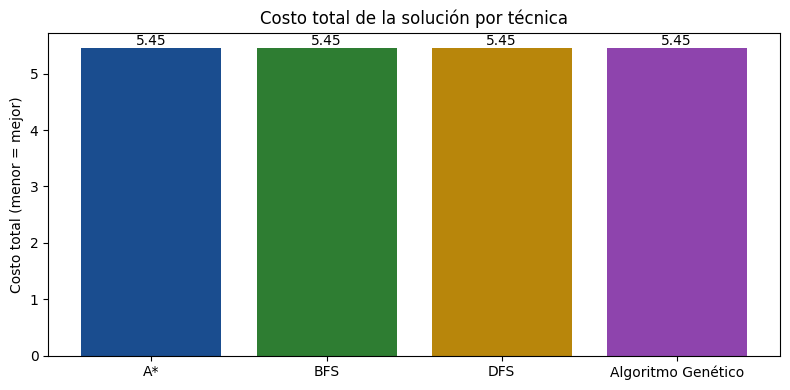

In [8]:
import matplotlib.pyplot as plt

nombres = [r["nombre"] for r in resultados]
costos = [r["costo_total"] for r in resultados]

plt.figure(figsize=(8,4))
barras = plt.bar(nombres, costos, color=["#1a4d8f","#2e7d32","#b8860b","#8e44ad"])
plt.title("Costo total de la solución por técnica")
plt.ylabel("Costo total (menor = mejor)")
for b, c in zip(barras, costos):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{c}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 9. Gráfica: esfuerzo (nodos explorados / generaciones)
Aquí se ve el **valor de la heurística**: A\* explora mucho menos que BFS/DFS.

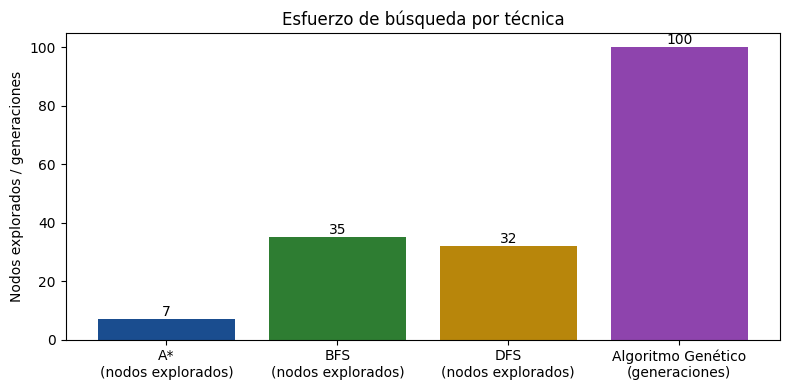

In [9]:
esfuerzos = [r["esfuerzo"] for r in resultados]
etiquetas = [f"{r['nombre']}\n({r['esfuerzo_etiqueta']})" for r in resultados]

plt.figure(figsize=(8,4))
barras = plt.bar(etiquetas, esfuerzos, color=["#1a4d8f","#2e7d32","#b8860b","#8e44ad"])
plt.title("Esfuerzo de búsqueda por técnica")
plt.ylabel("Nodos explorados / generaciones")
for b, e in zip(barras, esfuerzos):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{e}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 10. Gráfica: tiempo de ejecución por técnica

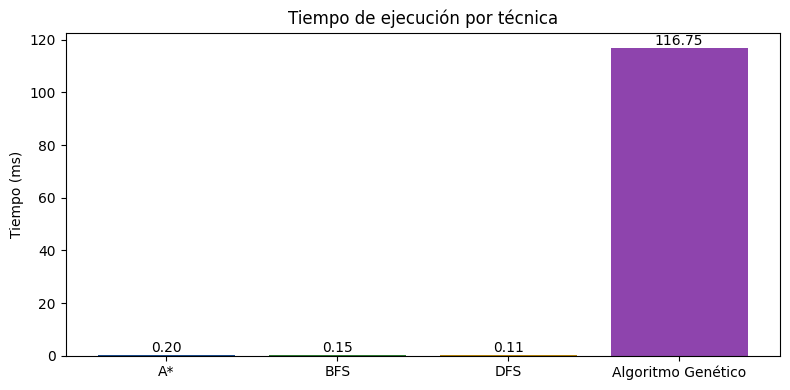

In [10]:
tiempos = [r["tiempo_ms"] for r in resultados]

plt.figure(figsize=(8,4))
barras = plt.bar(nombres, tiempos, color=["#1a4d8f","#2e7d32","#b8860b","#8e44ad"])
plt.title("Tiempo de ejecución por técnica")
plt.ylabel("Tiempo (ms)")
for b, t in zip(barras, tiempos):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{t:.2f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 11. Gráfica: curva de convergencia del genético
Mejor costo encontrado en cada generación. Debe **bajar y estabilizarse**.

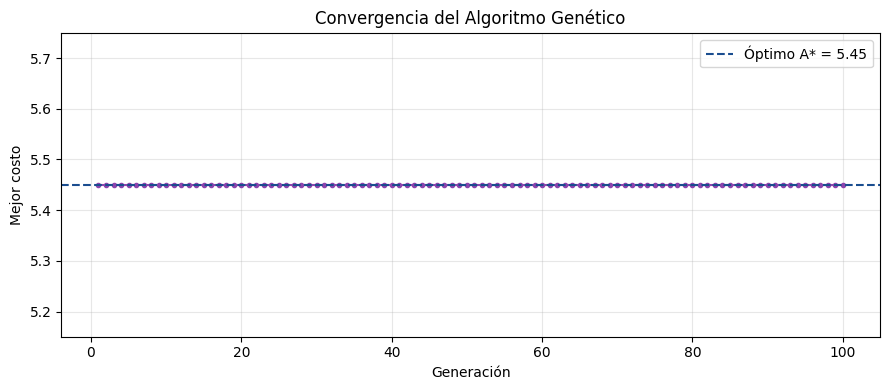

In [11]:
conv = res_gen["convergencia"]

plt.figure(figsize=(9,4))
plt.plot(range(1, len(conv)+1), conv, marker="o", markersize=3, color="#8e44ad")
plt.axhline(res_astar["costo_total"], color="#1a4d8f", linestyle="--",
            label=f"Óptimo A* = {res_astar['costo_total']}")
plt.title("Convergencia del Algoritmo Genético")
plt.xlabel("Generación"); plt.ylabel("Mejor costo")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Gráfica: árbol de búsqueda de A\*

Cada nodo es un estado expandido (etiquetado con f/g/h); las aristas conectan
cada nodo con su padre. Muestra **cómo A\* recorrió el espacio** hasta la
solución.

/tmp/ipykernel_1432/69141070.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis("off"); plt.tight_layout(); plt.show()


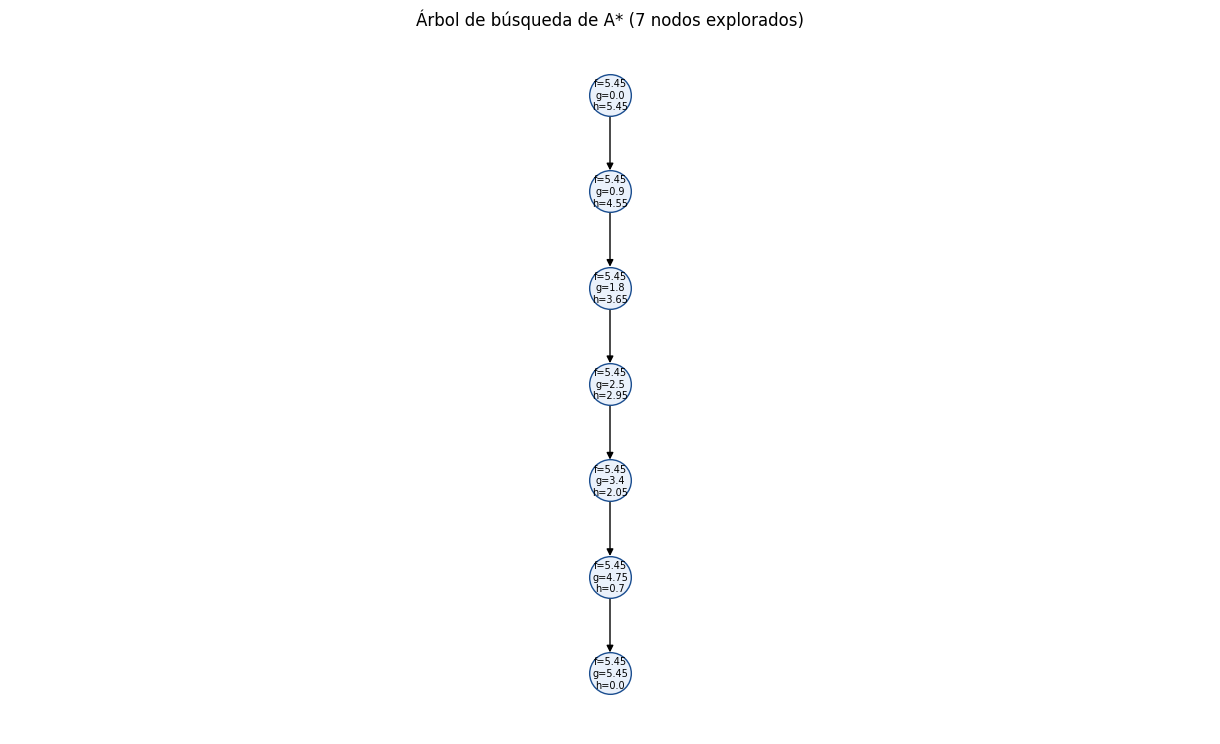

In [12]:
import networkx as nx

arbol = res_astar["arbol"]
G = nx.DiGraph()
for (idn, idp, indice, g, h, f) in arbol:
    G.add_node(idn, nivel=indice, label=f"f={f}\ng={g}\nh={h}")
    if idp is not None:
        G.add_edge(idp, idn)

# Layout por niveles (profundidad de la búsqueda)
niveles = {}
for (idn, idp, indice, g, h, f) in arbol:
    niveles.setdefault(indice, []).append(idn)
pos = {}
for nivel, ids in niveles.items():
    n = len(ids)
    for k, idn in enumerate(ids):
        pos[idn] = (k - n/2, -nivel)

plt.figure(figsize=(12, 7))
nx.draw(G, pos, with_labels=False, node_size=900, node_color="#eaf1fb",
        edgecolors="#1a4d8f", arrows=True)
labels = {idn: G.nodes[idn]["label"] for idn in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7)
plt.title(f"Árbol de búsqueda de A* ({len(arbol)} nodos explorados)")
plt.axis("off"); plt.tight_layout(); plt.show()

## 13. Paleta y estilo común
Colores consistentes para todas las gráficas siguientes.

In [13]:
import matplotlib.pyplot as plt

COLORES = {"A*": "#1a4d8f", "BFS": "#2e7d32", "DFS": "#b8860b", "Algoritmo Genético": "#8e44ad"}
COLOR_CAT = {"Academica": "#1a4d8f", "Académica": "#1a4d8f", "Financiera": "#2e7d32",
             "Tecnologica": "#b8860b", "Tecnológica": "#b8860b", "Administrativa": "#8e44ad"}
COLOR_PRI = {"Alta": "#c0392b", "Media": "#b8860b", "Baja": "#2e7d32"}

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
print("Estilo configurado.")

Estilo configurado.


## 14. Panel resumen (4 métricas a la vez)
Todas las métricas clave en una sola figura.

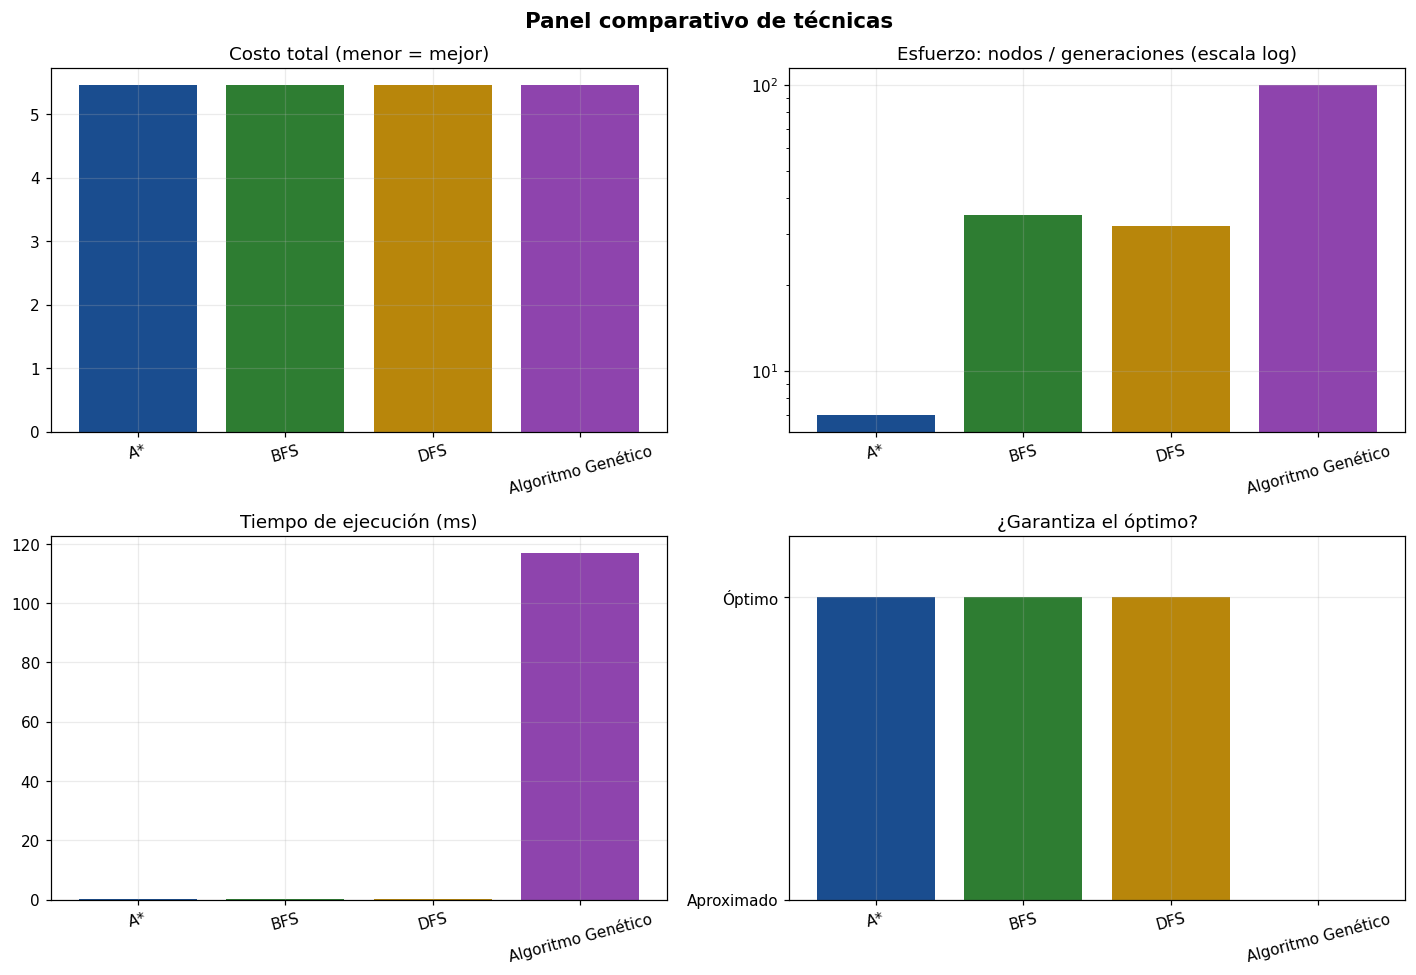

In [14]:
nombres = [r["nombre"] for r in resultados]
cols = [COLORES[n] for n in nombres]

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0,0].bar(nombres, [r["costo_total"] for r in resultados], color=cols)
axs[0,0].set_title("Costo total (menor = mejor)")
axs[0,1].bar(nombres, [r["esfuerzo"] for r in resultados], color=cols)
axs[0,1].set_yscale("log")
axs[0,1].set_title("Esfuerzo: nodos / generaciones (escala log)")
axs[1,0].bar(nombres, [r["tiempo_ms"] for r in resultados], color=cols)
axs[1,0].set_title("Tiempo de ejecución (ms)")
axs[1,1].bar(nombres, [1 if r["optimo"] else 0 for r in resultados], color=cols)
axs[1,1].set_ylim(0, 1.2); axs[1,1].set_yticks([0,1])
axs[1,1].set_yticklabels(["Aproximado", "Óptimo"])
axs[1,1].set_title("¿Garantiza el óptimo?")
for ax in axs.flat:
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Panel comparativo de técnicas", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 15. Distribución de las solicitudes
Reparto por **categoría** y por **prioridad**.

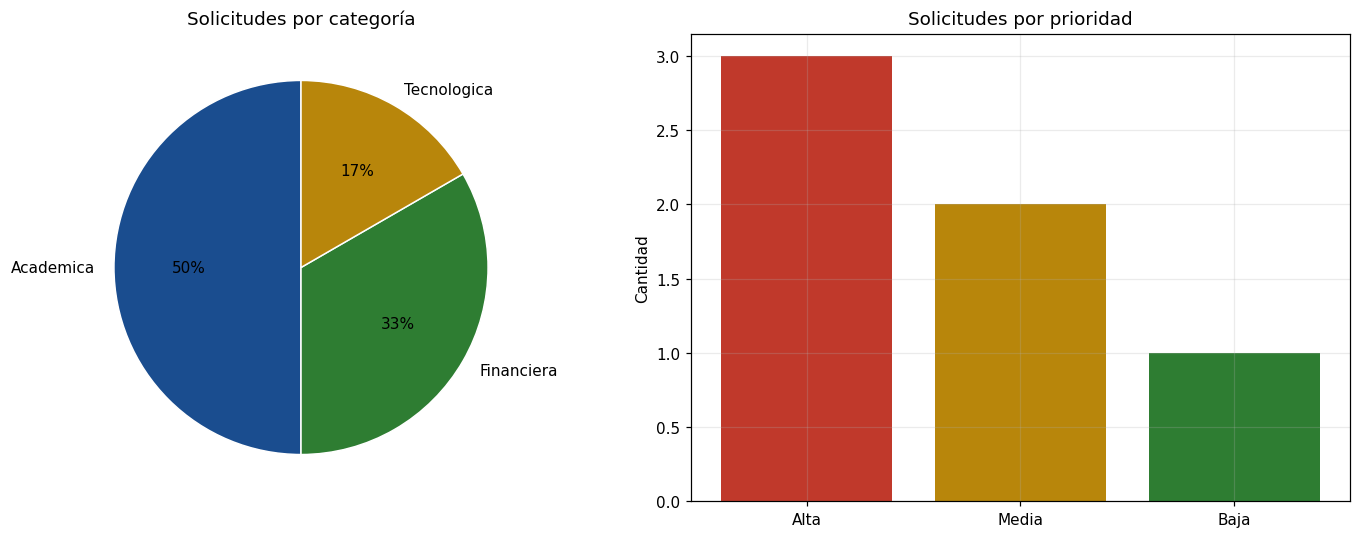

In [15]:
from collections import Counter

cat_count = Counter(s.categoria for s in solicitudes)
pri_count = Counter(s.prioridad for s in solicitudes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.pie(cat_count.values(), labels=list(cat_count.keys()), autopct="%1.0f%%",
        colors=[COLOR_CAT.get(c, "#888") for c in cat_count],
        startangle=90, wedgeprops={"edgecolor": "white"})
ax1.set_title("Solicitudes por categoría")
orden_pri = [p for p in ["Alta", "Media", "Baja"] if p in pri_count]
ax2.bar(orden_pri, [pri_count[p] for p in orden_pri],
        color=[COLOR_PRI[p] for p in orden_pri])
ax2.set_title("Solicitudes por prioridad")
ax2.set_ylabel("Cantidad")
plt.tight_layout(); plt.show()

## 16. Funcionarios: carga y capacidad
Datos que alimentan la función de costo.

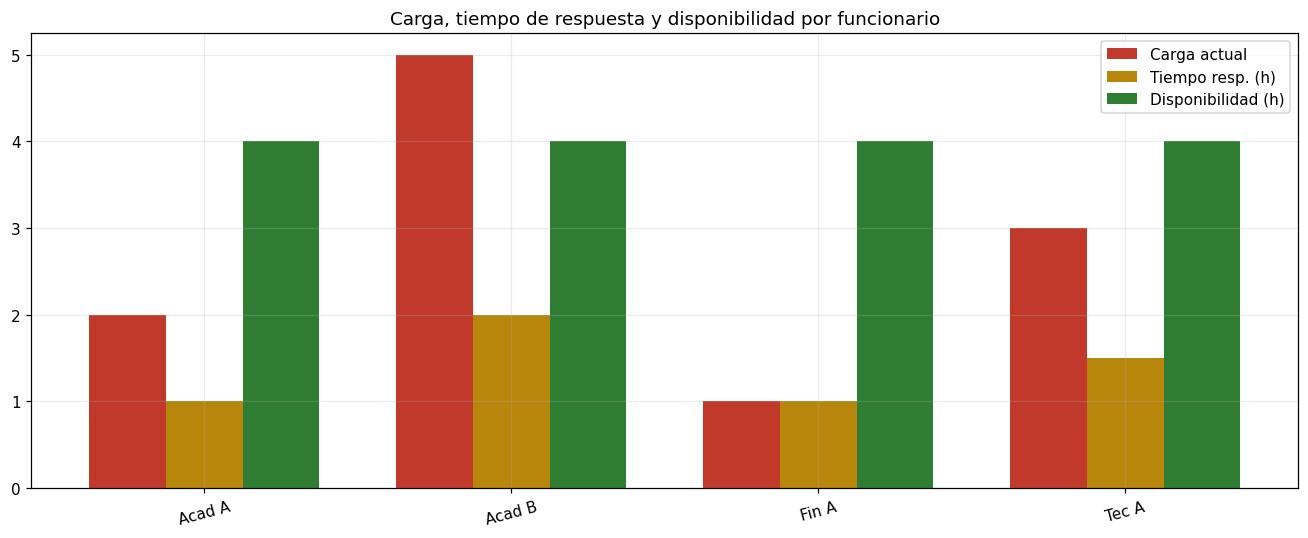

In [16]:
import numpy as np

nombres_f = [f.nombre for f in funcionarios]
x = np.arange(len(nombres_f)); ancho = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - ancho, [f.carga_actual for f in funcionarios], ancho, label="Carga actual", color="#c0392b")
ax.bar(x, [f.tiempo_promedio_respuesta for f in funcionarios], ancho, label="Tiempo resp. (h)", color="#b8860b")
ax.bar(x + ancho, [f.disponibilidad_horas for f in funcionarios], ancho, label="Disponibilidad (h)", color="#2e7d32")
ax.set_xticks(x); ax.set_xticklabels(nombres_f, rotation=15)
ax.set_title("Carga, tiempo de respuesta y disponibilidad por funcionario")
ax.legend()
plt.tight_layout(); plt.show()

## 17. Resultado de A\*: ¿a quién se asignó cada solicitud?

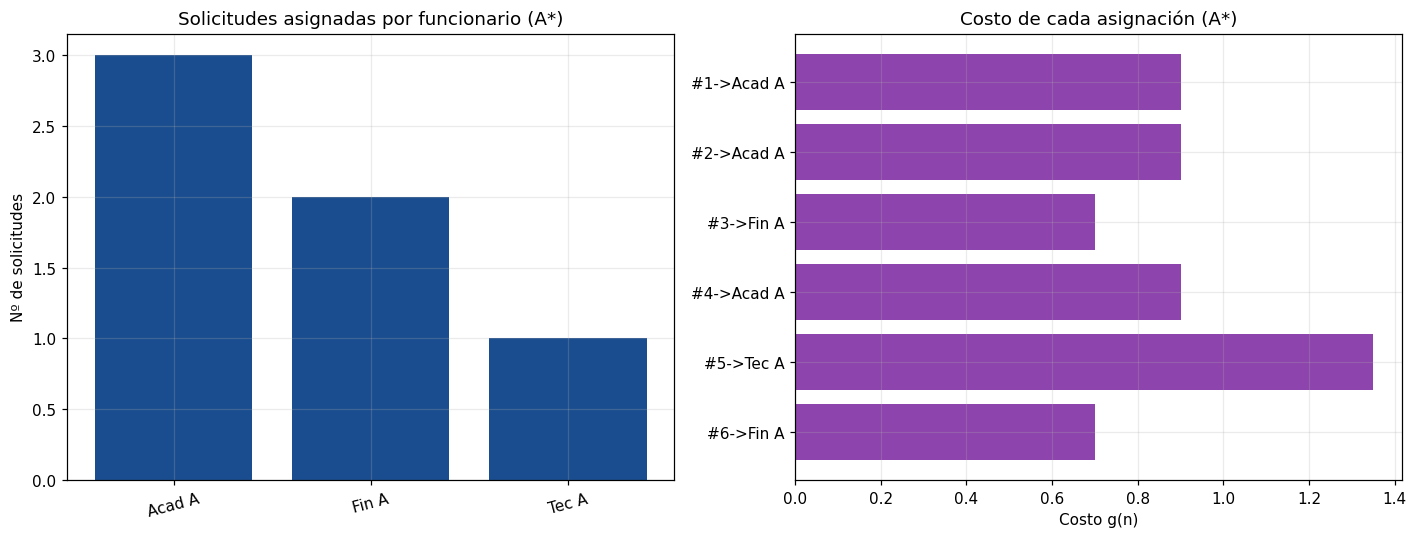

In [17]:
asig = res_astar["asignaciones"]  # (solicitud_id, func_id, func_nombre, costo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
recibidas = Counter(a[2] for a in asig)
ax1.bar(list(recibidas.keys()), list(recibidas.values()), color="#1a4d8f")
ax1.set_title("Solicitudes asignadas por funcionario (A*)")
ax1.set_ylabel("Nº de solicitudes")
ax1.tick_params(axis="x", rotation=15)
etiquetas = [f"#{a[0]}->{a[2]}" for a in asig]
ax2.barh(etiquetas, [a[3] for a in asig], color="#8e44ad")
ax2.set_title("Costo de cada asignación (A*)")
ax2.set_xlabel("Costo g(n)")
ax2.invert_yaxis()
plt.tight_layout(); plt.show()

## 18. Escalabilidad: ¿cómo crecen los nodos al aumentar el lote?

**El argumento más fuerte** de la rúbrica: BFS/DFS explotan exponencialmente y
A\* se mantiene muy por debajo gracias a la heurística. Usa lotes sintéticos
crecientes (no toca la BD). Baja `MAX_LOTE` si tarda.

In [18]:
import random as _rnd

CATS = ["Academica", "Financiera", "Tecnologica"]
PRIS = ["Alta", "Media", "Baja"]
FUNCS_POR_CAT = 3   # varios funcionarios por categoría => hay ramificación real
MAX_LOTE = 8        # baja este número si tarda (BFS/DFS crecen exponencialmente)

def lote_sintetico(n, semilla=0):
    r = _rnd.Random(semilla)
    sols = [Solicitud(i+1, r.choice(CATS), r.choice(PRIS)) for i in range(n)]
    funcs = []
    fid = 100
    for c in CATS:
        for k in range(FUNCS_POR_CAT):
            funcs.append(Funcionario(fid, f"{c[:3]}{k}", c,
                                     r.randint(0,4), r.choice([1.0,1.5,2.0]), n))
            fid += 1
    return sols, funcs

tamanos = list(range(2, MAX_LOTE+1))
nodos_astar, nodos_bfs, nodos_dfs = [], [], []
t_astar, t_bfs, t_dfs, t_gen = [], [], [], []
for n in tamanos:
    s, f = lote_sintetico(n)
    ra = ejecutar_astar(s, f); rb = ejecutar_busqueda_ciega(s, f, "BFS")
    rd = ejecutar_busqueda_ciega(s, f, "DFS"); rg = ejecutar_genetico(s, f, generaciones=60)
    nodos_astar.append(ra["esfuerzo"]); nodos_bfs.append(rb["esfuerzo"]); nodos_dfs.append(rd["esfuerzo"])
    t_astar.append(ra["tiempo_ms"]); t_bfs.append(rb["tiempo_ms"]); t_dfs.append(rd["tiempo_ms"]); t_gen.append(rg["tiempo_ms"])
print("Escalabilidad calculada para lotes:", tamanos)
print("Nodos A*: ", nodos_astar)
print("Nodos BFS:", nodos_bfs)

Escalabilidad calculada para lotes: [2, 3, 4, 5, 6, 7, 8]
Nodos A*:  [3, 10, 22, 8, 11, 88, 26]
Nodos BFS: [13, 40, 121, 364, 1093, 3280, 9841]


### 18.1 Nodos explorados vs tamaño del lote

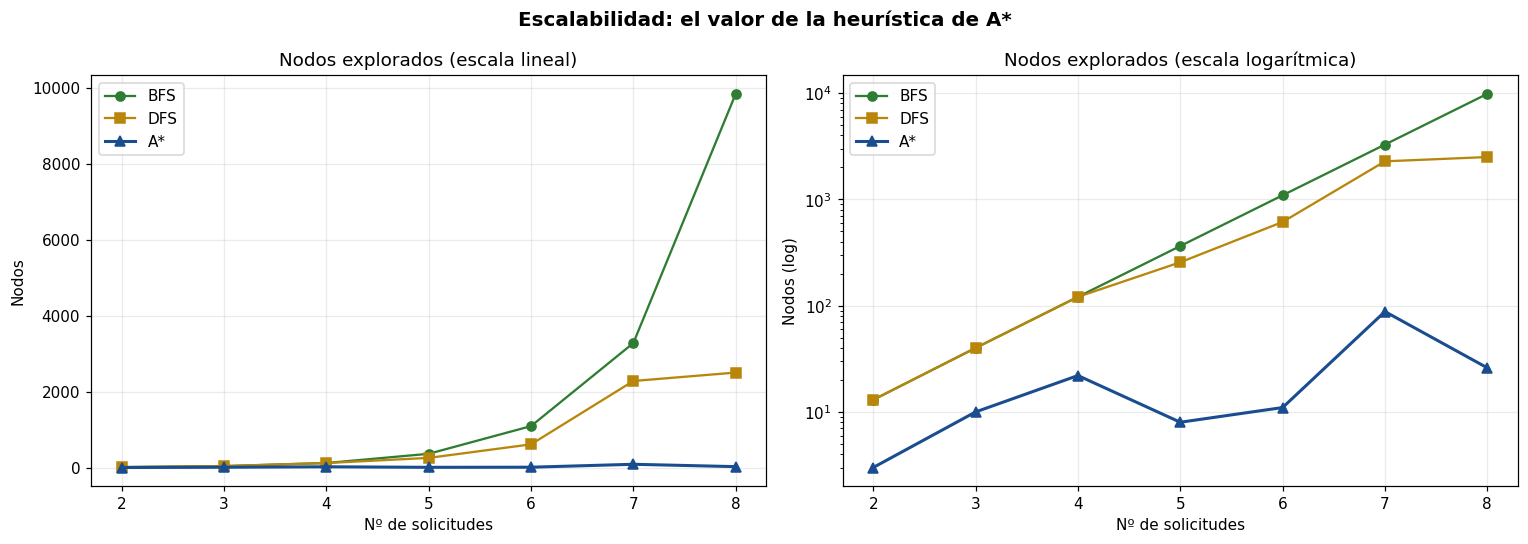

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(tamanos, nodos_bfs, "o-", label="BFS", color=COLORES["BFS"])
ax1.plot(tamanos, nodos_dfs, "s-", label="DFS", color=COLORES["DFS"])
ax1.plot(tamanos, nodos_astar, "^-", label="A*", color=COLORES["A*"], linewidth=2)
ax1.set_title("Nodos explorados (escala lineal)")
ax1.set_xlabel("Nº de solicitudes"); ax1.set_ylabel("Nodos"); ax1.legend()
ax2.semilogy(tamanos, nodos_bfs, "o-", label="BFS", color=COLORES["BFS"])
ax2.semilogy(tamanos, nodos_dfs, "s-", label="DFS", color=COLORES["DFS"])
ax2.semilogy(tamanos, nodos_astar, "^-", label="A*", color=COLORES["A*"], linewidth=2)
ax2.set_title("Nodos explorados (escala logarítmica)")
ax2.set_xlabel("Nº de solicitudes"); ax2.set_ylabel("Nodos (log)"); ax2.legend()
fig.suptitle("Escalabilidad: el valor de la heurística de A*", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 18.2 Tiempo de ejecución vs tamaño del lote

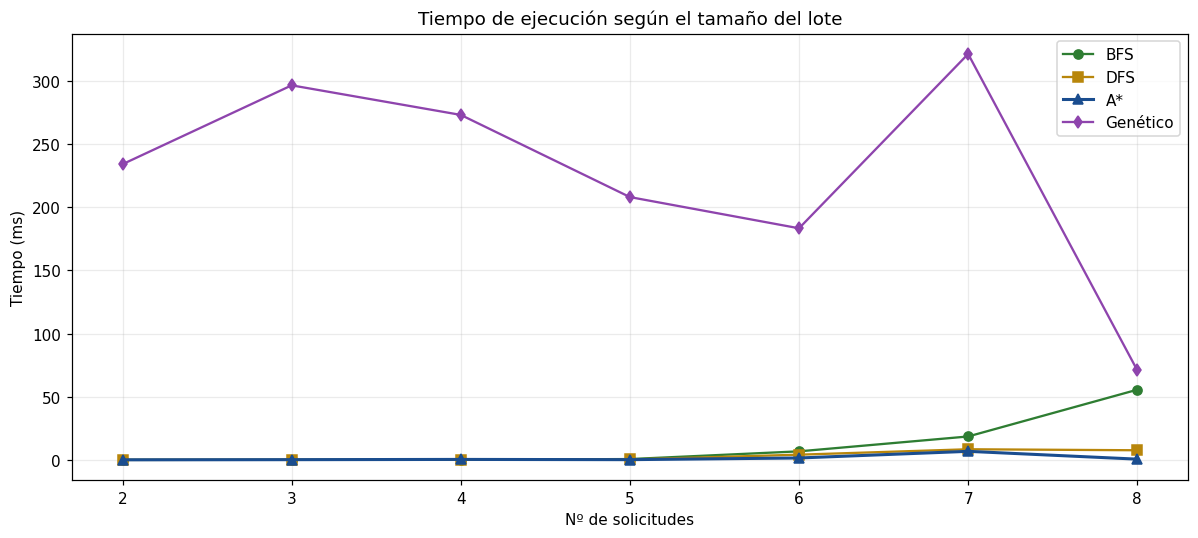

In [20]:
plt.figure(figsize=(11, 5))
plt.plot(tamanos, t_bfs, "o-", label="BFS", color=COLORES["BFS"])
plt.plot(tamanos, t_dfs, "s-", label="DFS", color=COLORES["DFS"])
plt.plot(tamanos, t_astar, "^-", label="A*", color=COLORES["A*"], linewidth=2)
plt.plot(tamanos, t_gen, "d-", label="Genético", color=COLORES["Algoritmo Genético"])
plt.title("Tiempo de ejecución según el tamaño del lote")
plt.xlabel("Nº de solicitudes"); plt.ylabel("Tiempo (ms)"); plt.legend()
plt.tight_layout(); plt.show()

## 19. Convergencia del genético (varias semillas)
Converge de forma estable cerca del óptimo de A\*.

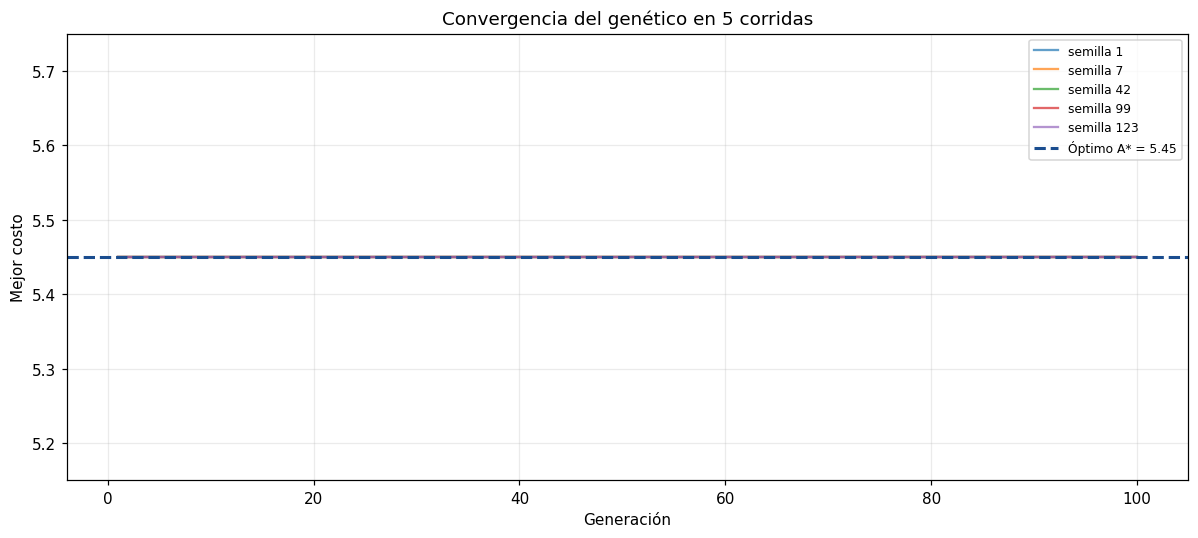

In [21]:
plt.figure(figsize=(11, 5))
for semilla in [1, 7, 42, 99, 123]:
    rg = ejecutar_genetico(solicitudes, funcionarios, semilla=semilla)
    conv = rg["convergencia"]
    plt.plot(range(1, len(conv)+1), conv, alpha=0.7, label=f"semilla {semilla}")
plt.axhline(res_astar["costo_total"], color="#1a4d8f", linestyle="--", linewidth=2,
            label=f"Óptimo A* = {res_astar['costo_total']}")
plt.title("Convergencia del genético en 5 corridas")
plt.xlabel("Generación"); plt.ylabel("Mejor costo")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 20. Comparación normalizada (escala 0–1)
Costo, esfuerzo y tiempo normalizados (más bajo = mejor).

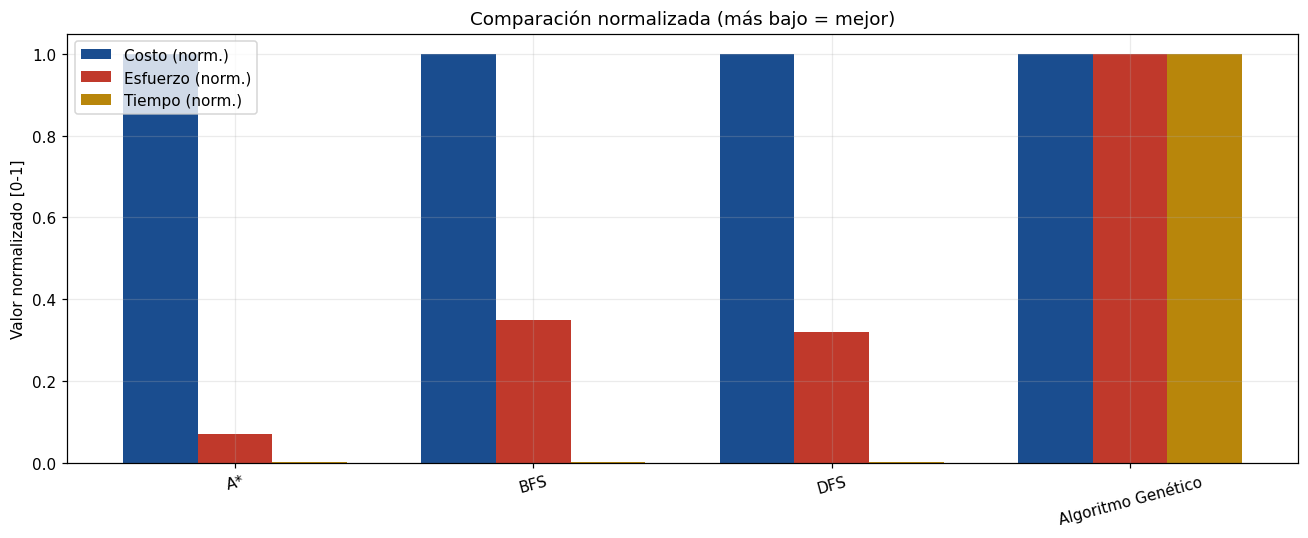

In [22]:
def norm_lista(vals):
    m = max(vals) or 1
    return [v/m for v in vals]

costo_n = norm_lista([r["costo_total"] for r in resultados])
esf_n = norm_lista([r["esfuerzo"] for r in resultados])
t_n = norm_lista([r["tiempo_ms"] for r in resultados])
x = np.arange(len(nombres)); ancho = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - ancho, costo_n, ancho, label="Costo (norm.)", color="#1a4d8f")
ax.bar(x, esf_n, ancho, label="Esfuerzo (norm.)", color="#c0392b")
ax.bar(x + ancho, t_n, ancho, label="Tiempo (norm.)", color="#b8860b")
ax.set_xticks(x); ax.set_xticklabels(nombres, rotation=15)
ax.set_title("Comparación normalizada (más bajo = mejor)")
ax.set_ylabel("Valor normalizado [0-1]"); ax.legend()
plt.tight_layout(); plt.show()

## 21. Análisis (para la slide 10)

- **A\*** y **BFS/DFS** llegan al **mismo costo óptimo** → las soluciones son
  correctas y comparables.
- **A\* explora muchos menos nodos** que BFS/DFS: la heurística admisible guía la
  búsqueda y evita expandir ramas inútiles → *valor de la búsqueda informada*.
- **BFS/DFS** son exhaustivas: garantizan el óptimo pero su costo crece
  exponencialmente con el nº de solicitudes (por eso esta comparación se ejecuta
  en Colab y no en el servidor).
- **El genético** no garantiza el óptimo, pero **converge** muy cerca en pocas
  generaciones y a tiempo casi constante → escala mejor en problemas grandes.

**Conclusión:** A\* es la mejor opción para este tamaño de problema (óptimo y
eficiente); el genético es la alternativa cuando el lote es demasiado grande para
una búsqueda exhaustiva.